# Threshold Target Evaluation

Does thresholding the label into up / no-move / down help separate
meaningful directional moves from noisy near-zero returns?

Focused on h1000 and h2000 — the most promising horizons from baseline evaluation.
Thresholds are defined in **bps** for economic interpretability.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.io import load_dataset_with_meta
from src.analysis.market_context import attach_segment_id
from src.analysis.baseline_eval import full_utc_days, split_by_utc_days
from src.dataset.schema import LABEL_COL

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

/Users/efremtsevv/scripts/hft/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
DS_DIR = Path("../data/datasets/binance/BTCUSDT_v2")

HORIZONS = {
    1000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h1000.parquet",
    2000: DS_DIR / "dataset_d4D_i100_tw1000_w600_h2000.parquet",
}

# Reference price for bps ↔ price conversion.
# Median midprice from book replay; used only for threshold conversion.
REF_PRICE = 69_492.49

# Threshold grid in bps.  Converts to price: thr_price = bps * 1e-4 * REF_PRICE.
# 0.05–0.25 bps = micro-noise filtering; 0.50–4.00 bps = economically meaningful.
THRESHOLDS_BPS = [0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 4.00]

FEATURES = ["microprice_minus_mid", "imbalance_1"]

# Split: same as baseline_evaluation — 1 full UTC day each.
TRAIN_DAYS = 1
VAL_DAYS = 1
TEST_DAYS = 1

## Load & split

In [3]:
def load_and_split(horizon_ms_key):
    df, meta = load_dataset_with_meta(HORIZONS[horizon_ms_key])
    attach_segment_id(df, int(meta["interval_ms"]))
    h = int(meta["horizon_ms"])
    days = full_utc_days(df)
    need = TRAIN_DAYS + VAL_DAYS + TEST_DAYS
    assert len(days) >= need, f"h={h}ms: need {need} full days, have {len(days)}"
    t = days[:TRAIN_DAYS]
    v = days[TRAIN_DAYS:TRAIN_DAYS + VAL_DAYS]
    s = days[TRAIN_DAYS + VAL_DAYS:TRAIN_DAYS + VAL_DAYS + TEST_DAYS]
    parts = split_by_utc_days(df, t, v, s, h)
    return parts, h

data = {}
for h_ms in HORIZONS:
    parts, h = load_and_split(h_ms)
    data[h_ms] = {"parts": parts, "h": h}
    print()

  Purged 10 rows from train tail
  Purged 10 rows from val tail
train:    835,157 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:58.900000+00:00]
  val:    845,039 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:58.900000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]

  Purged 20 rows from train tail
  Purged 20 rows from val tail
train:    835,117 rows  [2026-03-24 00:00:00+00:00 → 2026-03-24 23:59:57.900000+00:00]
  val:    844,999 rows  [2026-03-25 00:00:00+00:00 → 2026-03-25 23:59:57.900000+00:00]
 test:    864,000 rows  [2026-03-26 00:00:00+00:00 → 2026-03-26 23:59:59.900000+00:00]



## Threshold target construction

For threshold T (in bps), convert to price: `thr_price = T * 1e-4 * REF_PRICE`.

- `up`      = label > thr_price
- `down`    = label < −thr_price
- `no_move` = otherwise

In [4]:
def bps_to_price(bps: float) -> float:
    """Convert a threshold in bps to an absolute price change."""
    return bps * 1e-4 * REF_PRICE


def make_class_target(label: np.ndarray, thr_bps: float) -> np.ndarray:
    """Return -1 (down) / 0 (no_move) / +1 (up) given threshold in bps."""
    thr = bps_to_price(thr_bps)
    return np.where(label > thr, 1, np.where(label < -thr, -1, 0))


# Show conversion table for reference
print("Threshold grid — bps → price:")
for b in THRESHOLDS_BPS:
    print(f"  {b:5.2f} bps  →  ${bps_to_price(b):.4f}")

Threshold grid — bps → price:
   0.05 bps  →  $0.3475
   0.10 bps  →  $0.6949
   0.25 bps  →  $1.7373
   0.50 bps  →  $3.4746
   1.00 bps  →  $6.9492
   2.00 bps  →  $13.8985
   4.00 bps  →  $27.7970


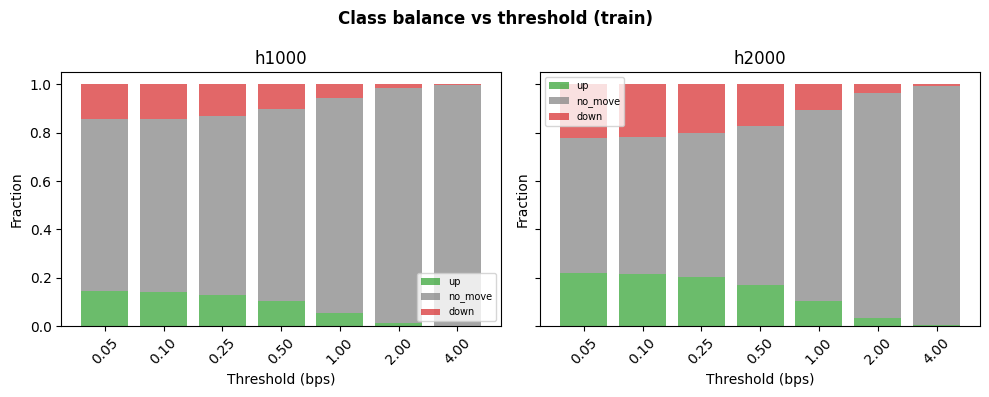

In [5]:
# Class balance vs threshold (train)
fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4), sharey=True)
if len(data) == 1:
    axes = [axes]

bps_labels = [f"{b:.2f}" for b in THRESHOLDS_BPS]

for ax, (h_ms, d) in zip(axes, data.items()):
    label = d["parts"]["train"][LABEL_COL].values
    up_frac, no_frac, dn_frac = [], [], []
    for b in THRESHOLDS_BPS:
        ct = make_class_target(label, b)
        up_frac.append((ct == 1).mean())
        no_frac.append((ct == 0).mean())
        dn_frac.append((ct == -1).mean())
    x = np.arange(len(THRESHOLDS_BPS))
    ax.bar(x, up_frac, label="up", alpha=0.7, color="tab:green")
    ax.bar(x, no_frac, bottom=up_frac, label="no_move", alpha=0.7, color="tab:gray")
    ax.bar(x, dn_frac, bottom=np.array(up_frac) + np.array(no_frac),
           label="down", alpha=0.7, color="tab:red")
    ax.set_xticks(x)
    ax.set_xticklabels(bps_labels, rotation=45)
    ax.set_xlabel("Threshold (bps)")
    ax.set_ylabel("Fraction")
    ax.set_title(f"h{h_ms}")
    ax.legend(fontsize=7)

fig.suptitle("Class balance vs threshold (train)", fontweight="bold")
fig.tight_layout()
plt.show()

## Directional evaluation on non-trivial moves

For each threshold, restrict evaluation to rows where `|label| > threshold`
(i.e. the class target is non-zero). This tests whether the baseline features
predict direction better when micro-noise is filtered out.

Three metrics per threshold:
- **Directional accuracy**: `P(sign(feature) == class_target | class_target != 0)`
- **Conditional edge (long)**: `E[label | pred=UP, class_target != 0]` in bps
- **Conditional edge (short)**: `E[-label | pred=DOWN, class_target != 0]` in bps

In [6]:
def eval_at_threshold(score, label, thr_bps):
    """Evaluate sign(score) on non-trivial moves defined by thr_bps."""
    ct = make_class_target(label, thr_bps)
    pred = np.sign(score)
    nontrivial = ct != 0

    # Directional accuracy: among non-trivial moves with non-zero prediction
    mask = nontrivial & (pred != 0)
    acc = (pred[mask] == ct[mask]).mean() if mask.sum() > 0 else np.nan

    # Conditional edge on non-trivial moves
    long_mask = (pred > 0) & nontrivial
    short_mask = (pred < 0) & nontrivial
    long_edge = label[long_mask].mean() / REF_PRICE * 1e4 if long_mask.sum() > 0 else np.nan
    short_edge = -label[short_mask].mean() / REF_PRICE * 1e4 if short_mask.sum() > 0 else np.nan

    # Directional purity: P(ct == pred_sign | pred_sign, nontrivial)
    long_purity = (ct[long_mask] == 1).mean() if long_mask.sum() > 0 else np.nan
    short_purity = (ct[short_mask] == -1).mean() if short_mask.sum() > 0 else np.nan

    return {
        "dir_accuracy": acc,
        "long_edge_bps": long_edge,
        "short_edge_bps": short_edge,
        "long_purity": long_purity,
        "short_purity": short_purity,
        "coverage": nontrivial.mean(),
    }

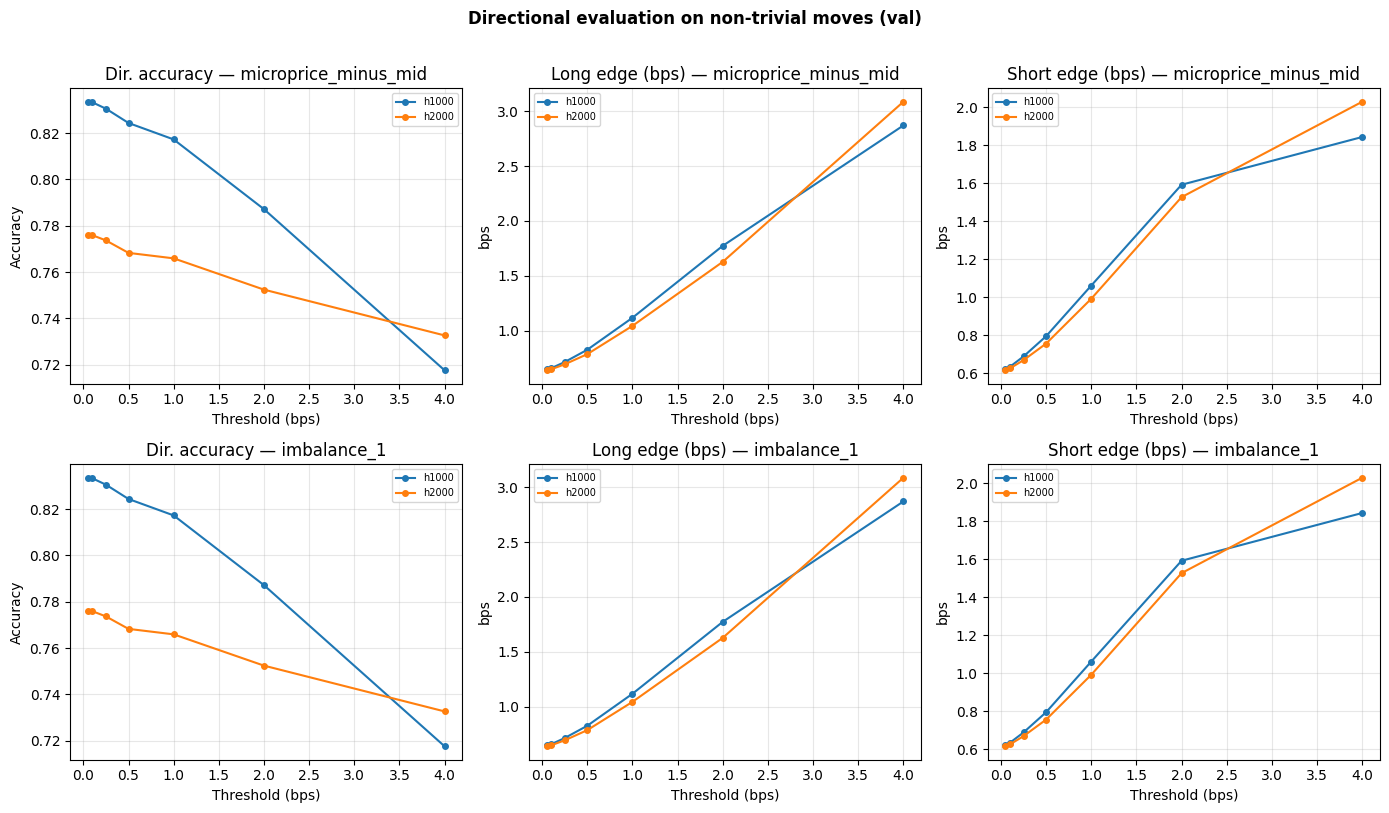

In [7]:
# Compute metrics for all horizons × thresholds × features
rows = []
for h_ms, d in data.items():
    val = d["parts"]["val"]
    label = val[LABEL_COL].values
    for feat in FEATURES:
        score = val[feat].values
        for b in THRESHOLDS_BPS:
            res = eval_at_threshold(score, label, b)
            rows.append({"horizon": h_ms, "feature": feat, "thr_bps": b, **res})

eval_df = pd.DataFrame(rows)

# Plot: directional accuracy + conditional edge (2 rows: one per feature)
fig, axes = plt.subplots(len(FEATURES), 3, figsize=(14, 4 * len(FEATURES)), squeeze=False)

for row, feat in enumerate(FEATURES):
    sub = eval_df[eval_df["feature"] == feat]
    for h_ms in data:
        h_sub = sub[sub["horizon"] == h_ms]
        axes[row, 0].plot(h_sub["thr_bps"], h_sub["dir_accuracy"],
                          "o-", markersize=4, label=f"h{h_ms}")
        axes[row, 1].plot(h_sub["thr_bps"], h_sub["long_edge_bps"],
                          "o-", markersize=4, label=f"h{h_ms}")
        axes[row, 2].plot(h_sub["thr_bps"], h_sub["short_edge_bps"],
                          "o-", markersize=4, label=f"h{h_ms}")

    for ax, title in zip(axes[row], ["Dir. accuracy", "Long edge (bps)", "Short edge (bps)"]):
        ax.set_xlabel("Threshold (bps)")
        ax.set_title(f"{title} — {feat}")
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    axes[row, 0].set_ylabel("Accuracy")
    axes[row, 1].set_ylabel("bps")
    axes[row, 2].set_ylabel("bps")

fig.suptitle("Directional evaluation on non-trivial moves (val)", fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

## Directional purity and coverage trade-off

**Purity** = `P(class_target matches prediction | prediction is non-zero, move is non-trivial)`.
As threshold increases, only larger moves survive — purity should improve, but coverage drops.

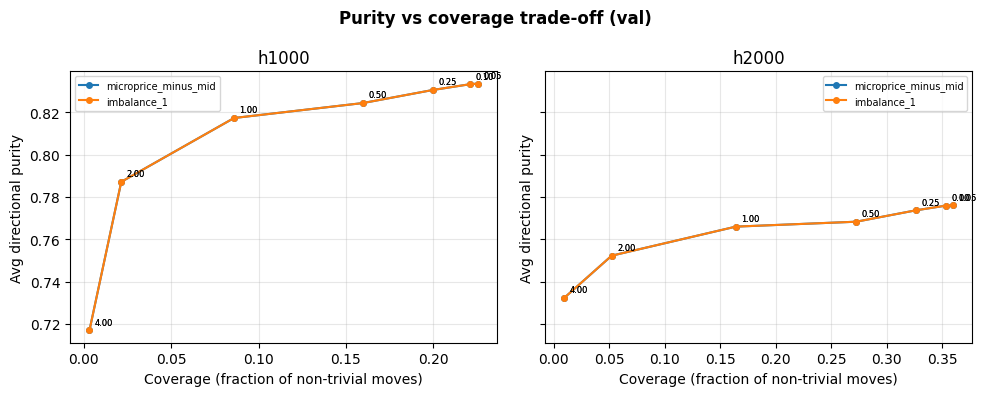

In [8]:
# Purity vs coverage trade-off
fig, axes = plt.subplots(1, len(data), figsize=(5 * len(data), 4), sharey=True)
if len(data) == 1:
    axes = [axes]

for ax, (h_ms, _) in zip(axes, data.items()):
    for feat in FEATURES:
        sub = eval_df[(eval_df["horizon"] == h_ms) & (eval_df["feature"] == feat)]
        avg_purity = (sub["long_purity"] + sub["short_purity"]) / 2
        ax.plot(sub["coverage"], avg_purity, "o-", markersize=4, label=feat)
        # Annotate bps values
        for _, r in sub.iterrows():
            ax.annotate(f'{r["thr_bps"]:.2f}', (r["coverage"], (r["long_purity"] + r["short_purity"]) / 2),
                        fontsize=6, textcoords="offset points", xytext=(4, 4))
    ax.set_xlabel("Coverage (fraction of non-trivial moves)")
    ax.set_ylabel("Avg directional purity")
    ax.set_title(f"h{h_ms}")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

fig.suptitle("Purity vs coverage trade-off (val)", fontweight="bold")
fig.tight_layout()
plt.show()

## Summary table

Key metrics at each threshold for the best-performing feature per horizon.

In [9]:
# Compact summary table: best feature per horizon at each threshold
for h_ms in data:
    print(f"\n--- h{h_ms} (val) ---")
    sub = eval_df[eval_df["horizon"] == h_ms].copy()
    # Pick feature with higher dir_accuracy at each threshold
    idx = sub.groupby("thr_bps")["dir_accuracy"].idxmax()
    best = sub.loc[idx, ["thr_bps", "feature", "dir_accuracy", "long_edge_bps",
                          "short_edge_bps", "coverage"]].reset_index(drop=True)
    best.columns = ["bps", "feature", "dir_acc", "long_bps", "short_bps", "coverage"]
    display(best.style.format({
        "bps": "{:.2f}", "dir_acc": "{:.4f}",
        "long_bps": "{:.4f}", "short_bps": "{:.4f}", "coverage": "{:.3f}",
    }).hide(axis="index"))


--- h1000 (val) ---


bps,feature,dir_acc,long_bps,short_bps,coverage
0.05,microprice_minus_mid,0.8335,0.6457,0.6220,0.225
0.10,microprice_minus_mid,0.8333,0.6566,0.6343,0.221
0.25,microprice_minus_mid,0.8305,0.7130,0.6885,0.200
0.50,microprice_minus_mid,0.8244,0.8251,0.7948,0.160
1.00,microprice_minus_mid,0.8173,1.1167,1.0613,0.086
2.00,microprice_minus_mid,0.7872,1.7730,1.5916,0.022
4.00,microprice_minus_mid,0.7176,2.8708,1.8429,0.003



--- h2000 (val) ---


bps,feature,dir_acc,long_bps,short_bps,coverage
0.05,microprice_minus_mid,0.7760,0.6377,0.6157,0.359
0.10,microprice_minus_mid,0.7759,0.6469,0.6258,0.354
0.25,microprice_minus_mid,0.7737,0.6923,0.6690,0.326
0.50,microprice_minus_mid,0.7683,0.7851,0.7560,0.273
1.00,microprice_minus_mid,0.7659,1.0429,0.9919,0.164
2.00,microprice_minus_mid,0.7524,1.6270,1.5265,0.052
4.00,microprice_minus_mid,0.7327,3.0870,2.0282,0.009
